<a href="https://colab.research.google.com/github/hiraljoshi93/Machine_Learning/blob/main/Copy_of_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Vadodara_9_Para_CSV.csv to Vadodara_9_Para_CSV (1).csv
First 5 Rows of Dataset
   Year Month     RF     ATE      CC     DTR     MTE   PET   RCETO      VP  \
0  1901   Jan  0.730  19.902  10.130  16.733  28.307  5.99  0.2383  10.729   
1  1901   Feb  0.000  21.056   8.800  17.070  29.612  6.66  0.1287  11.190   
2  1901   Mar  1.354  27.360  19.044  16.617  35.669  7.66  0.0246  14.361   
3  1901   Apr  3.272  30.574  18.162  15.168  38.172  8.43  0.0144  18.889   
4  1901   May  2.382  32.754  22.094  12.989  39.246  8.38  0.0000  24.508   

      WDF  
0  0.6776  
1  0.0000  
2  0.4136  
3  0.6618  
4  0.5836  

Column Names:
Index(['Year', 'Month', 'RF', 'ATE', 'CC', 'DTR', 'MTE', 'PET', 'RCETO', 'VP',
       'WDF'],
      dtype='object')

Missing Values:
ATE      0
CC       0
DTR      0
MTE      0
PET      0
RCETO    0
VP       0
WDF      0
RF       0
dtype: int64

Shape of Standardized Data:
(1224, 8)

Explained Variance Ratio:
PC1 : 0.5330
PC2 : 0.3422
PC3 : 0.0838
PC4 : 0.

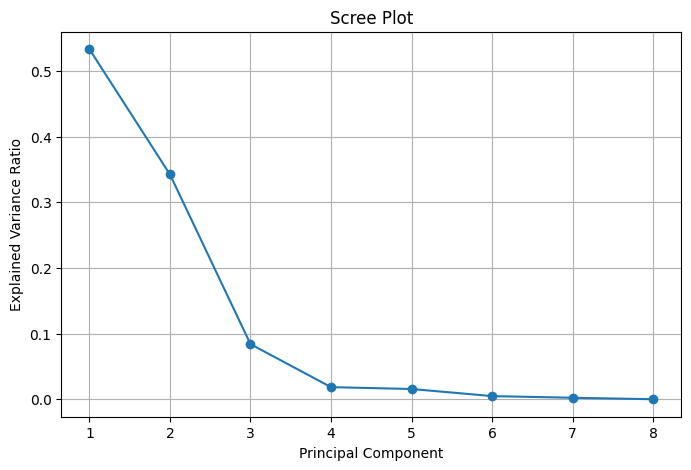


PCA Loadings Matrix:
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
ATE   -0.287643  0.474668  0.136244 -0.117410 -0.340201 -0.189035  0.071664   
CC    -0.465369 -0.117741  0.106745 -0.094965 -0.134933  0.843883  0.137152   
DTR    0.472069  0.061445 -0.107512 -0.053866  0.421884  0.242583  0.622906   
MTE   -0.051953  0.595676  0.095304 -0.170758 -0.144405 -0.075101  0.463471   
PET    0.170191  0.542560  0.228076 -0.091126  0.450661  0.295309 -0.570998   
RCETO  0.245500 -0.250306  0.921005 -0.060955 -0.115638 -0.056422  0.092493   
VP    -0.447899  0.073758  0.214310  0.704372  0.443603 -0.143775  0.185532   
WDF   -0.430460 -0.199392  0.056599 -0.661042  0.503951 -0.276730  0.064965   

            PC8  
ATE    0.709223  
CC     0.000176  
DTR    0.366156  
MTE   -0.602438  
PET   -0.000417  
RCETO  0.000220  
VP     0.000135  
WDF   -0.000030  


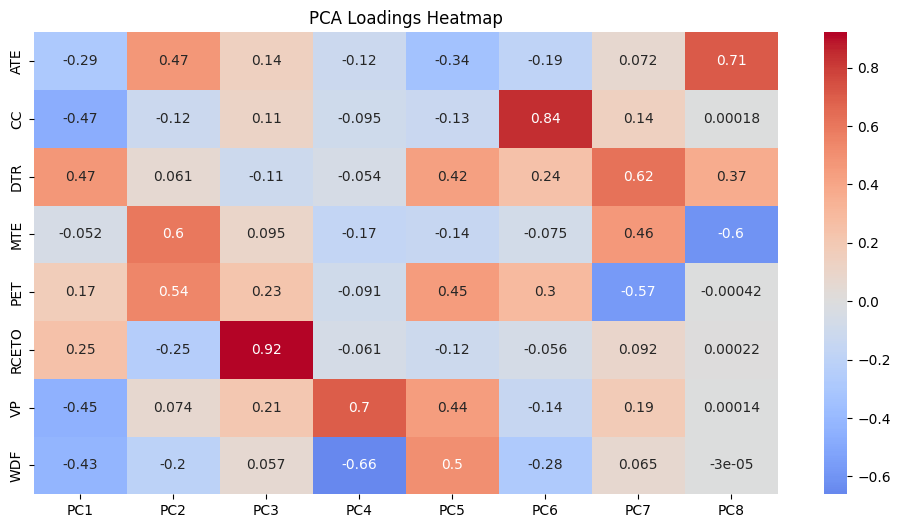


Variable Importance Based on PC1:
      Variable  Contribution_to_PC1
DTR        DTR             0.472069
CC          CC             0.465369
VP          VP             0.447899
WDF        WDF             0.430460
ATE        ATE             0.287643
RCETO    RCETO             0.245500
PET        PET             0.170191
MTE        MTE             0.051953


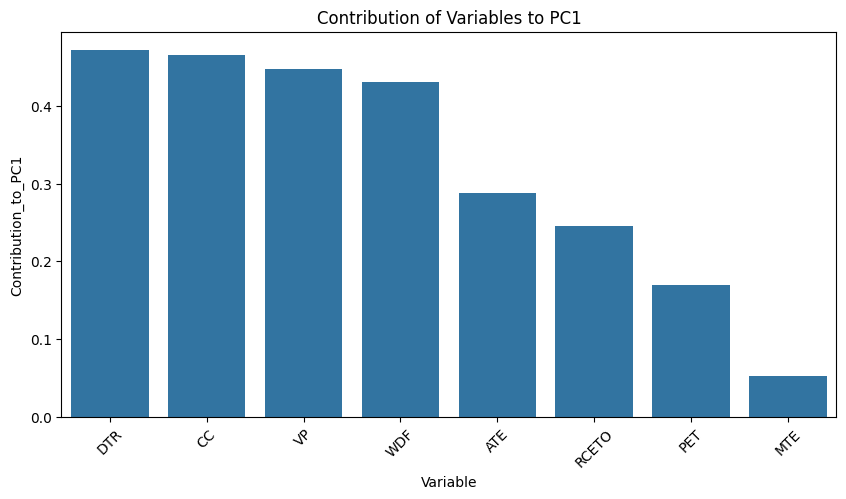

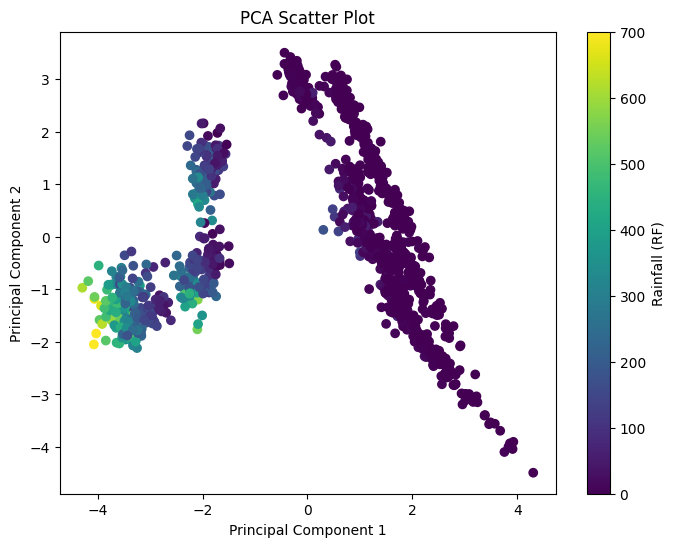


Correlation Matrix:
            ATE        CC       DTR       MTE       PET     RCETO        VP  \
ATE    1.000000  0.428944 -0.526840  0.856754  0.496821 -0.535718  0.635027   
CC     0.428944  1.000000 -0.961210 -0.078579 -0.494474 -0.339266  0.858804   
DTR   -0.526840 -0.961210  1.000000 -0.013040  0.438212  0.380499 -0.886067   
MTE    0.856754 -0.078579 -0.013040  1.000000  0.850358 -0.399182  0.209456   
PET    0.496821 -0.494474  0.438212  0.850358  1.000000 -0.060022 -0.170670   
RCETO -0.535718 -0.339266  0.380499 -0.399182 -0.060022  1.000000 -0.399073   
VP     0.635027  0.858804 -0.886067  0.209456 -0.170670 -0.399073  1.000000   
WDF    0.266081  0.914464 -0.874108 -0.217352 -0.566465 -0.279599  0.751001   
RF     0.236129  0.811400 -0.772678 -0.190943 -0.481965 -0.239895  0.673845   

            WDF        RF  
ATE    0.266081  0.236129  
CC     0.914464  0.811400  
DTR   -0.874108 -0.772678  
MTE   -0.217352 -0.190943  
PET   -0.566465 -0.481965  
RCETO -0.279599 -0.2

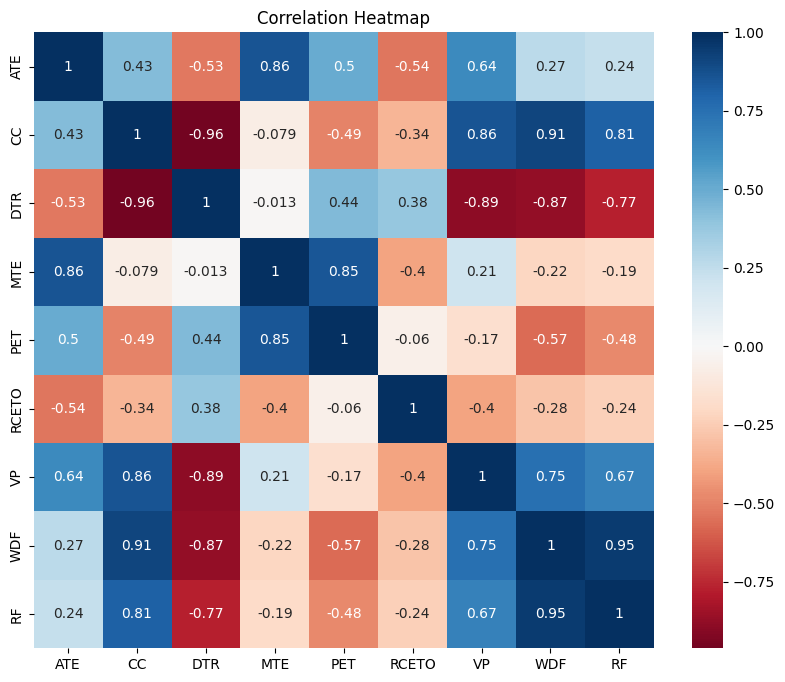

In [ ]:
# ============================================================
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# Impact of Climatic Parameters on Rainfall (RF)
# Google Colab Code
# ============================================================

# ------------------------------------------------------------
# STEP 1 : IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# STEP 2 : UPLOAD CSV FILE
# ------------------------------------------------------------

from google.colab import files

uploaded = files.upload()

# ------------------------------------------------------------
# STEP 3 : READ CSV FILE
# ------------------------------------------------------------

# Change filename if required
df = pd.read_csv("Vadodara_9_Para_CSV.csv")

# Display first 5 rows
print("First 5 Rows of Dataset")
print(df.head())

# ------------------------------------------------------------
# STEP 4 : CHECK COLUMN NAMES
# ------------------------------------------------------------

print("\nColumn Names:")
print(df.columns)

# ------------------------------------------------------------
# STEP 5 : SELECT VARIABLES
# ------------------------------------------------------------

# Target Variable
target = 'RF'

# Independent Variables
features = ['ATE', 'CC', 'DTR', 'MTE', 'PET', 'RCETO', 'VP', 'WDF']

# Create feature matrix
X = df[features]

# Rainfall variable
y = df[target]

# ------------------------------------------------------------
# STEP 6 : CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df[features + [target]].isnull().sum())

# Remove missing values if present
df = df.dropna()

# Update variables after removing missing values
X = df[features]
y = df[target]

# ------------------------------------------------------------
# STEP 7 : STANDARDIZE THE DATA
# ------------------------------------------------------------
# PCA requires standardization because variables
# may have different units and scales.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nShape of Standardized Data:")
print(X_scaled.shape)

# ------------------------------------------------------------
# STEP 8 : APPLY PCA
# ------------------------------------------------------------

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

# ------------------------------------------------------------
# STEP 9 : EXPLAINED VARIANCE
# ------------------------------------------------------------

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")

for i, var in enumerate(explained_variance):
    print(f"PC{i+1} : {var:.4f}")

# ------------------------------------------------------------
# STEP 10 : CUMULATIVE VARIANCE
# ------------------------------------------------------------

cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:")

for i, cum_var in enumerate(cumulative_variance):
    print(f"PC{i+1} : {cum_var:.4f}")

# ------------------------------------------------------------
# STEP 11 : SCREE PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# STEP 12 : PCA LOADINGS
# ------------------------------------------------------------
# Loadings indicate contribution/impact of variables
# on principal components.

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)

print("\nPCA Loadings Matrix:")
print(loadings)

# ------------------------------------------------------------
# STEP 13 : HEATMAP OF PCA LOADINGS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('PCA Loadings Heatmap')

plt.show()

# ------------------------------------------------------------
# STEP 14 : FIND MOST IMPORTANT VARIABLES
# ------------------------------------------------------------
# Variables with high absolute loading values
# contribute more strongly.

importance = pd.DataFrame({
    'Variable': features,
    'Contribution_to_PC1': np.abs(loadings['PC1'])
})

importance = importance.sort_values(
    by='Contribution_to_PC1',
    ascending=False
)

print("\nVariable Importance Based on PC1:")
print(importance)

# ------------------------------------------------------------
# STEP 15 : BAR PLOT OF VARIABLE IMPORTANCE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(
    x='Variable',
    y='Contribution_to_PC1',
    data=importance
)

plt.title('Contribution of Variables to PC1')

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# STEP 16 : PCA WITH 2 COMPONENTS
# ------------------------------------------------------------

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    data=X_pca_2,
    columns=['PC1', 'PC2']
)

# Add rainfall values
pca_df['RF'] = y.values

# ------------------------------------------------------------
# STEP 17 : PCA SCATTER PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['RF'],
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('PCA Scatter Plot')

plt.colorbar(scatter, label='Rainfall (RF)')

plt.show()

# ------------------------------------------------------------
# STEP 18 : CORRELATION MATRIX
# ------------------------------------------------------------
# This helps understand direct relationships
# between RF and climatic parameters.

corr_matrix = df[features + [target]].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# ------------------------------------------------------------
# STEP 19 : CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

# ============================================================
# END OF PCA ANALYSIS
# ============================================================


Explained Variance Ratio:

PC1 : 0.5330
PC2 : 0.3422
PC3 : 0.0838
PC4 : 0.0184
PC5 : 0.0156
PC6 : 0.0048
PC7 : 0.0022
PC8 : 0.0000

PCA Loadings:

            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
ATE   -0.287643  0.474668  0.136244 -0.117410 -0.340201 -0.189035  0.071664   
CC    -0.465369 -0.117741  0.106745 -0.094965 -0.134933  0.843883  0.137152   
DTR    0.472069  0.061445 -0.107512 -0.053866  0.421884  0.242583  0.622906   
MTE   -0.051953  0.595676  0.095304 -0.170758 -0.144405 -0.075101  0.463471   
PET    0.170191  0.542560  0.228076 -0.091126  0.450661  0.295309 -0.570998   
RCETO  0.245500 -0.250306  0.921005 -0.060955 -0.115638 -0.056422  0.092493   
VP    -0.447899  0.073758  0.214310  0.704372  0.443603 -0.143775  0.185532   
WDF   -0.430460 -0.199392  0.056599 -0.661042  0.503951 -0.276730  0.064965   

            PC8  
ATE    0.709223  
CC     0.000176  
DTR    0.366156  
MTE   -0.602438  
PET   -0.000417  
RCETO  0.000220  
VP     0.00013

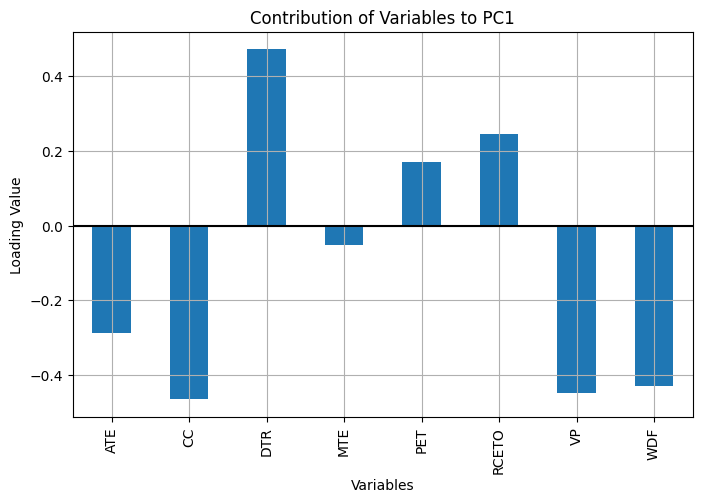

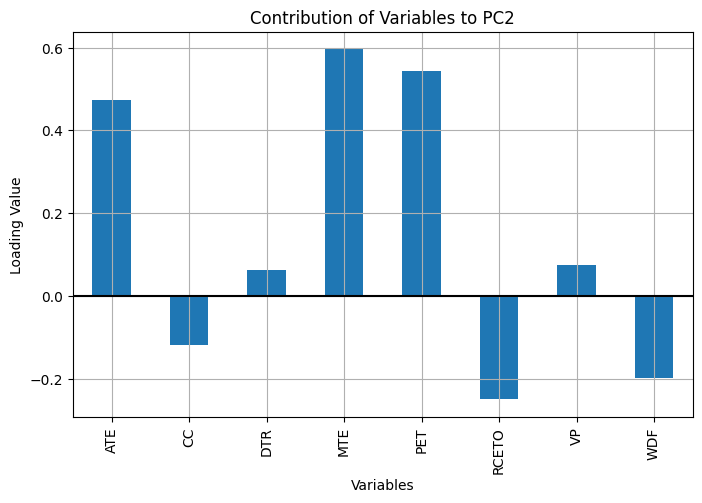

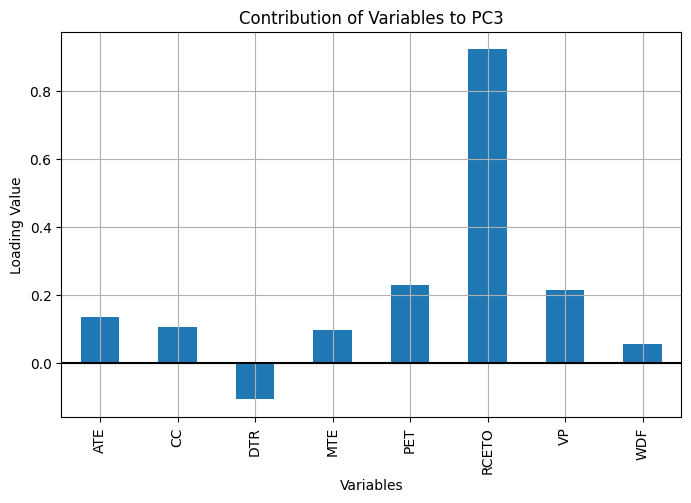

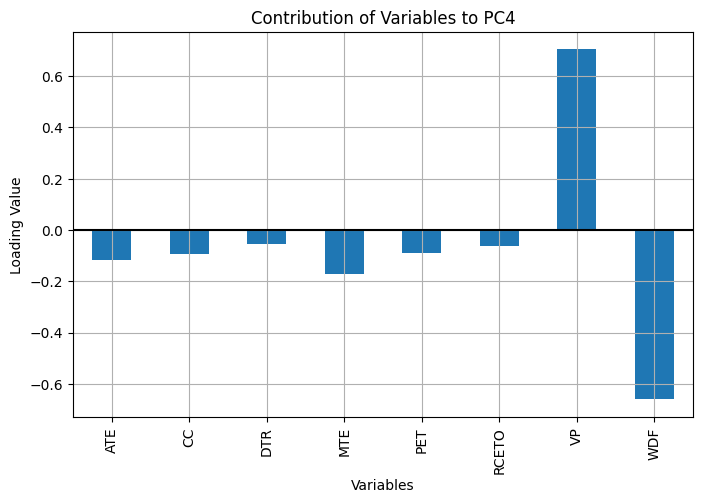

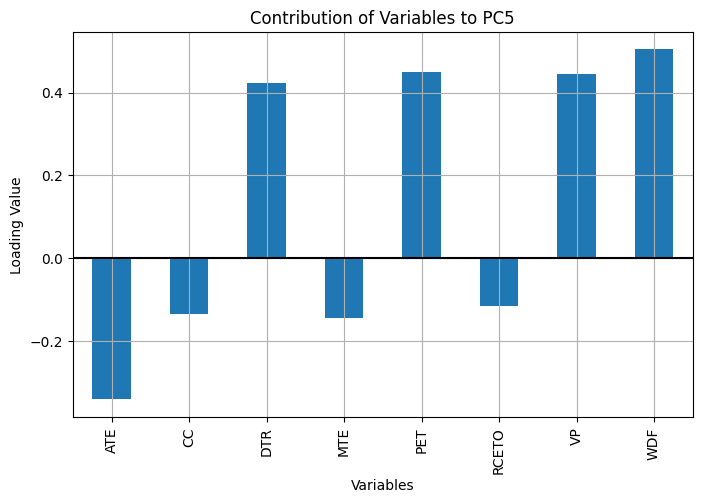

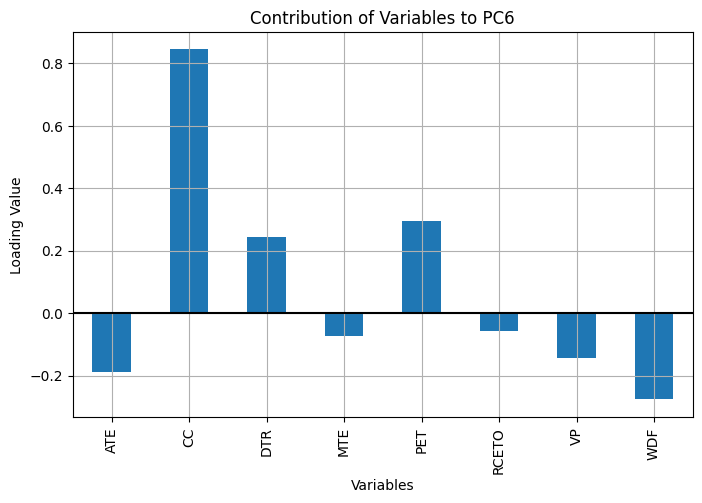

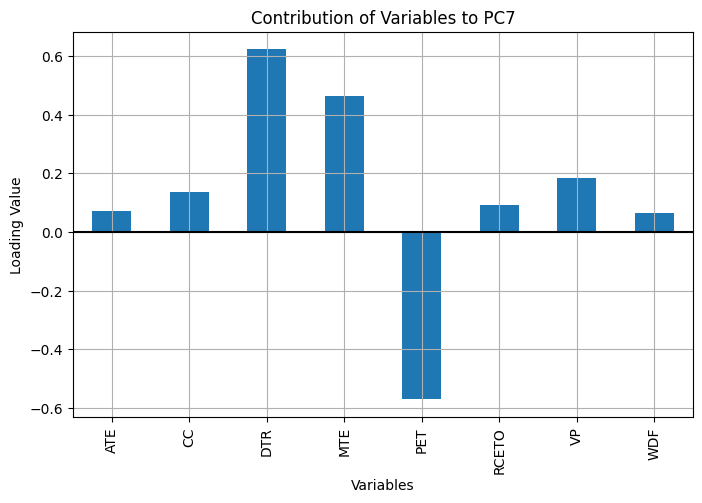

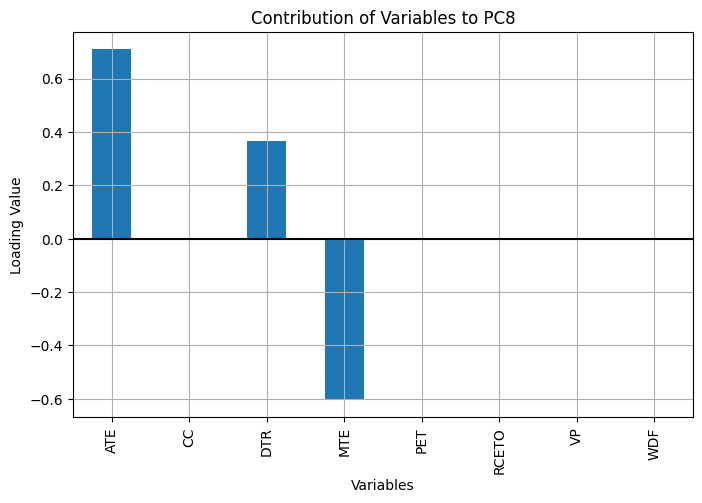

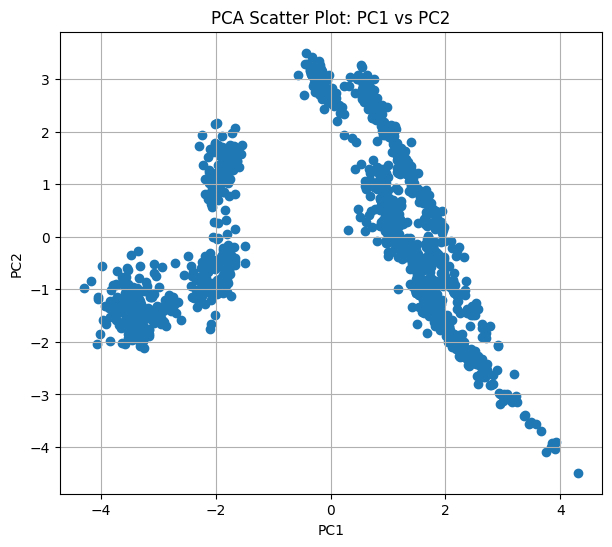

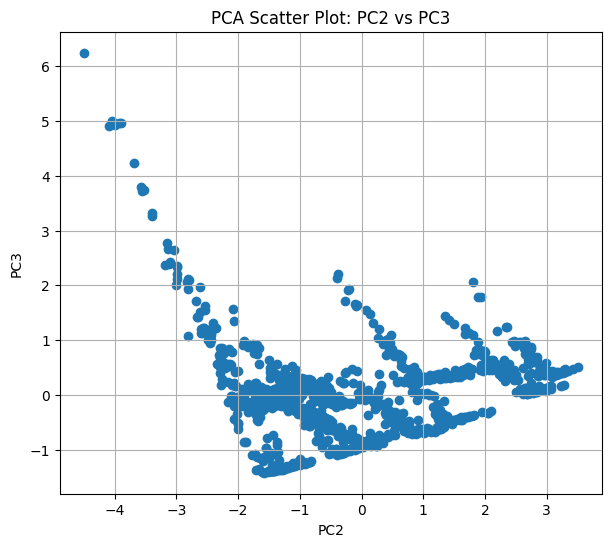

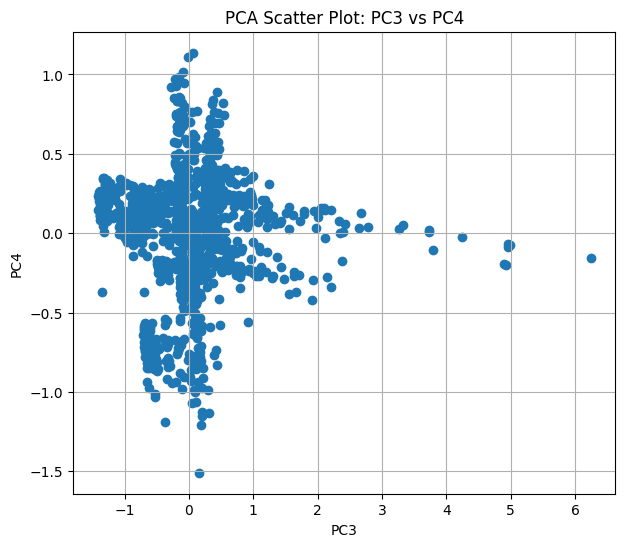

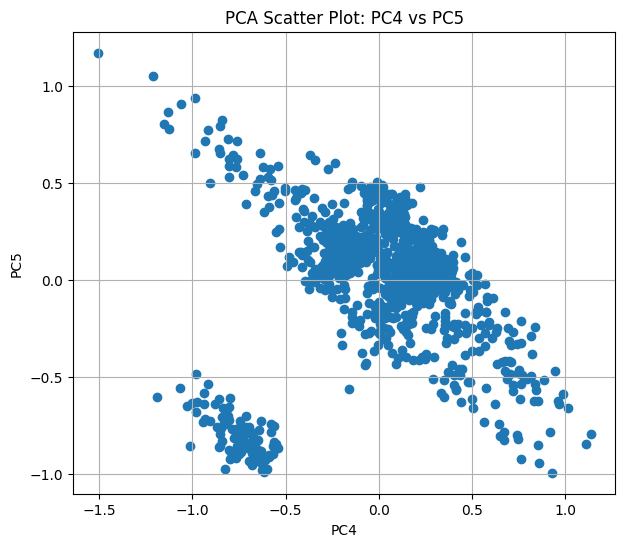

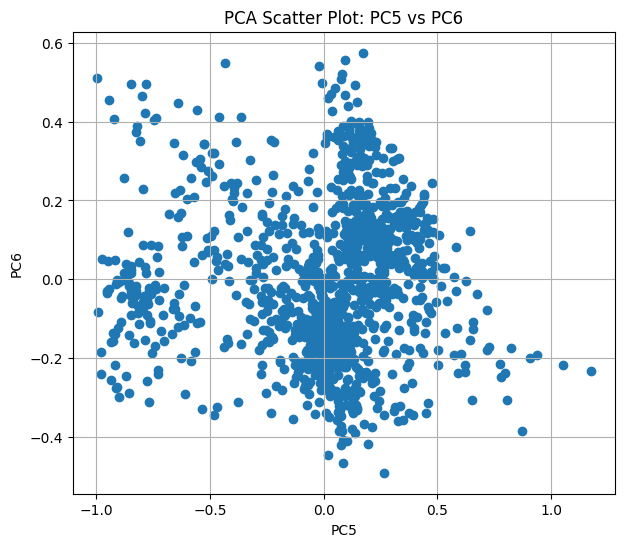

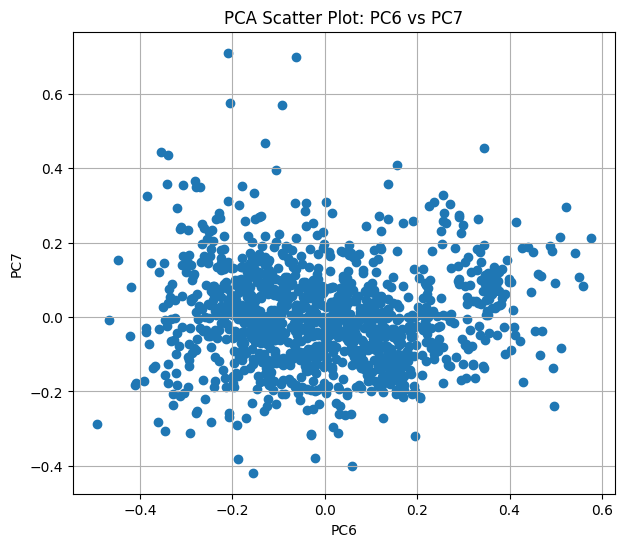

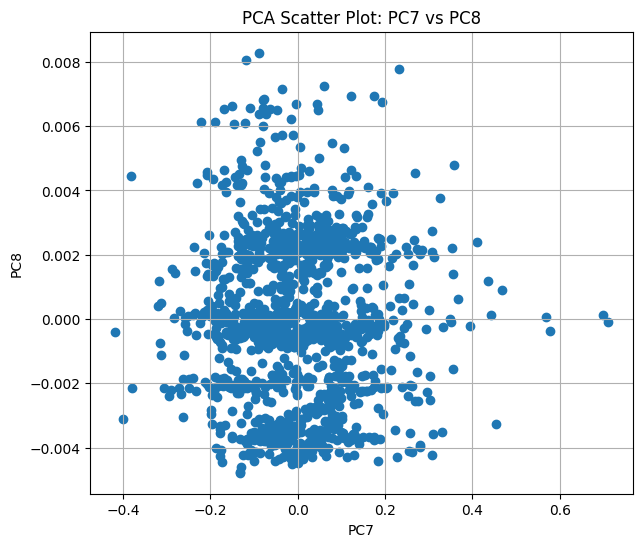

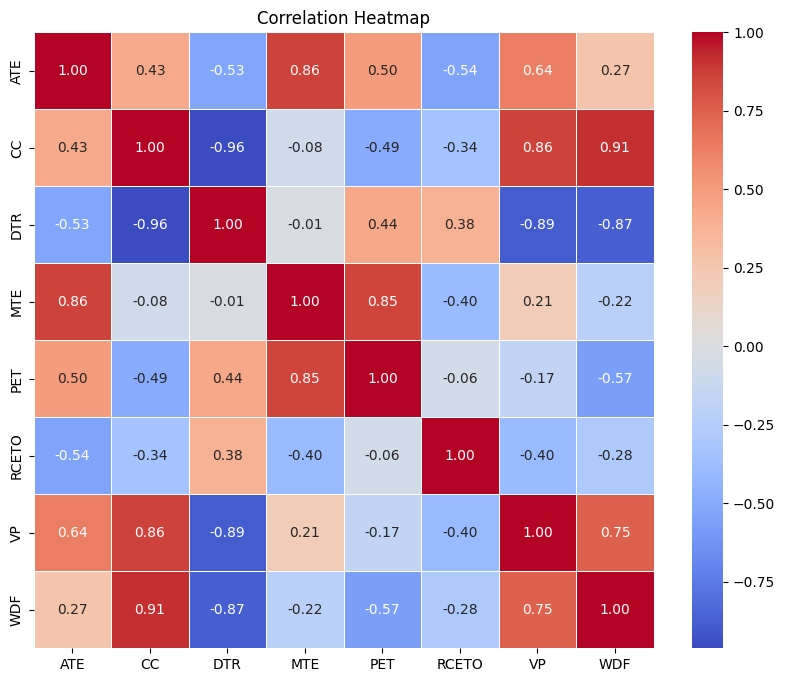


PCA Loadings saved as PCA_Loadings.csv
PCA Scores saved as PCA_Scores.csv


In [ ]:
# ============================================================
# PCA ANALYSIS FOR ALL PCs (PC1 to PC8)
# Additional Outputs:
# 1. Contribution of Variables to EACH PC
# 2. PCA Scatter Plot for EACH PC Combination
# 3. Correlation Heatmap
# ============================================================

# ----------------------------
# IMPORT LIBRARIES
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv('Vadodara_9_Para_CSV.csv')

# ----------------------------
# SELECT VARIABLES
# ----------------------------
X = df[['ATE','CC','DTR','MTE','PET','RCETO','VP','WDF']]

# ----------------------------
# STANDARDIZE DATA
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# APPLY PCA
# ----------------------------
pca = PCA(n_components=8)

principal_components = pca.fit_transform(X_scaled)

# ----------------------------
# EXPLAINED VARIANCE RATIO
# ----------------------------
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:\n")

for i, var in enumerate(explained_variance):
    print(f'PC{i+1} : {var:.4f}')

# ============================================================
# 1. CONTRIBUTION OF VARIABLES TO EACH PC
# ============================================================

# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(8)],
    index=X.columns
)

print("\nPCA Loadings:\n")
print(loadings)

# ------------------------------------------------------------
# Plot Contribution for EACH Principal Component
# ------------------------------------------------------------

for i in range(8):

    plt.figure(figsize=(8,5))

    contribution = loadings.iloc[:, i]

    contribution.plot(kind='bar')

    plt.title(f'Contribution of Variables to PC{i+1}')
    plt.ylabel('Loading Value')
    plt.xlabel('Variables')

    plt.axhline(0, color='black')

    plt.grid(True)

    plt.show()

# ============================================================
# 2. PCA SCATTER PLOTS
# ============================================================

# Create PCA dataframe
pca_df = pd.DataFrame(
    principal_components,
    columns=[f'PC{i+1}' for i in range(8)]
)

# ------------------------------------------------------------
# Scatter plots for consecutive PCs
# ------------------------------------------------------------

for i in range(7):

    plt.figure(figsize=(7,6))

    plt.scatter(
        pca_df[f'PC{i+1}'],
        pca_df[f'PC{i+2}']
    )

    plt.xlabel(f'PC{i+1}')
    plt.ylabel(f'PC{i+2}')

    plt.title(f'PCA Scatter Plot: PC{i+1} vs PC{i+2}')

    plt.grid(True)

    plt.show()

# ============================================================
# 3. CORRELATION HEATMAP
# ============================================================

# Correlation Matrix
corr_matrix = df[['ATE','CC','DTR','MTE','PET','RCETO','VP','WDF']].corr()

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

# ============================================================
# OPTIONAL:
# SAVE PCA LOADINGS TO CSV
# ============================================================

loadings.to_csv('PCA_Loadings.csv')

print("\nPCA Loadings saved as PCA_Loadings.csv")

# ============================================================
# OPTIONAL:
# SAVE PCA COMPONENT SCORES
# ============================================================

pca_df.to_csv('PCA_Scores.csv', index=False)

print("PCA Scores saved as PCA_Scores.csv")

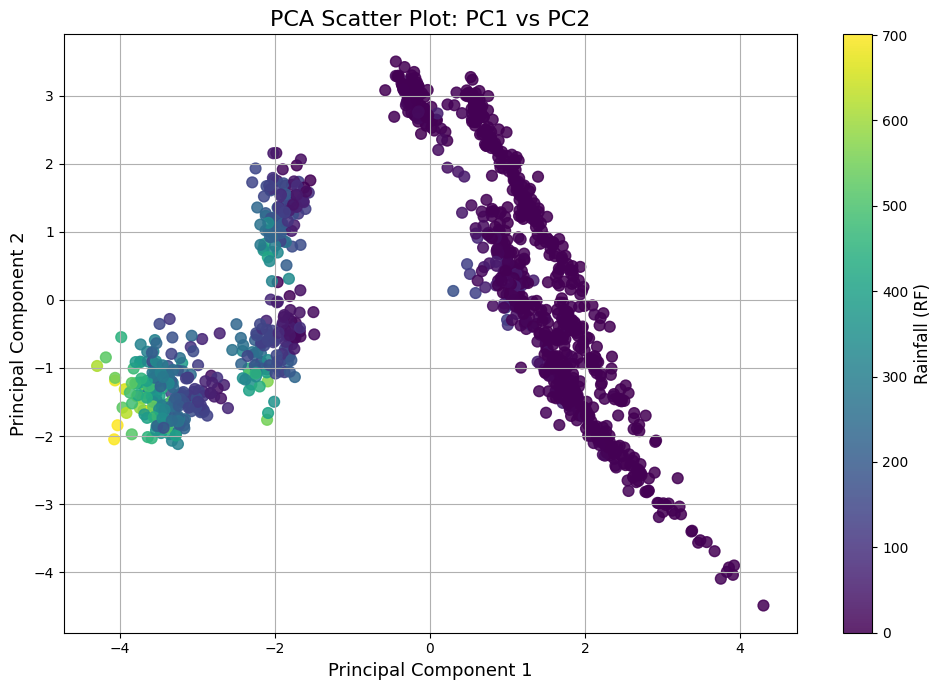

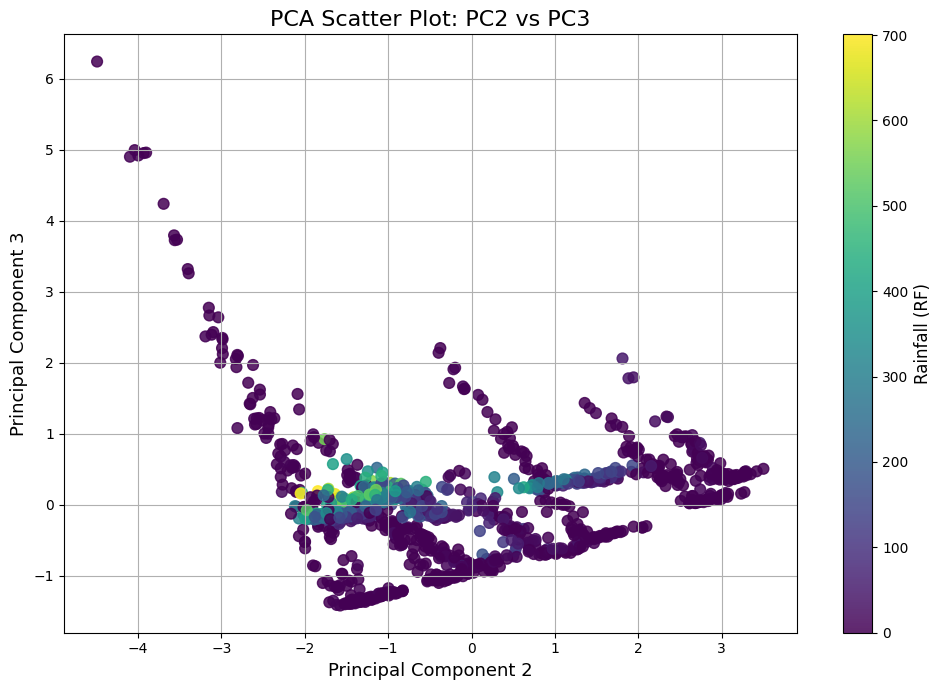

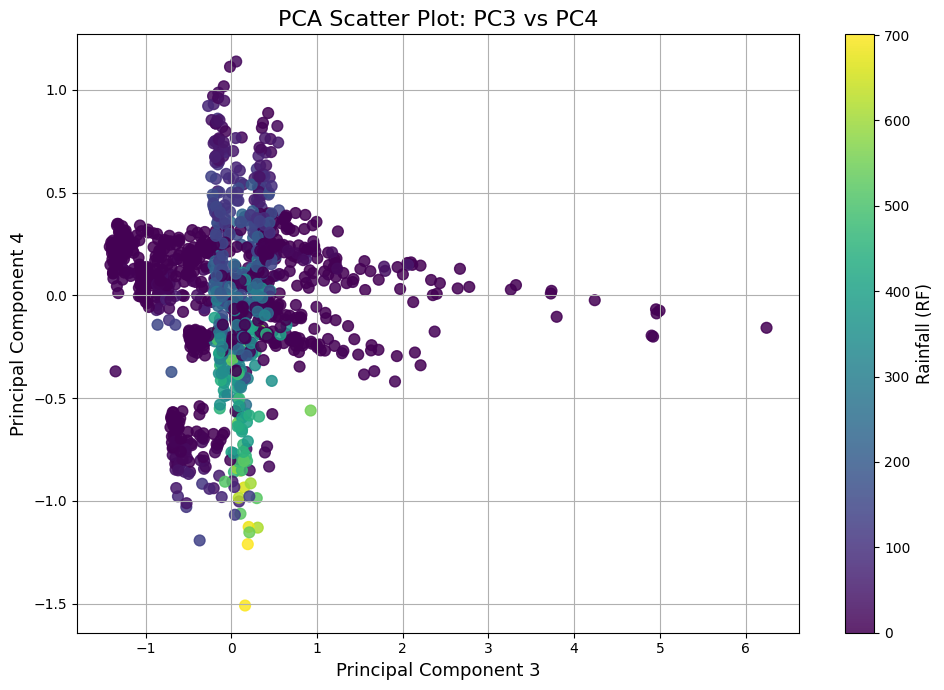

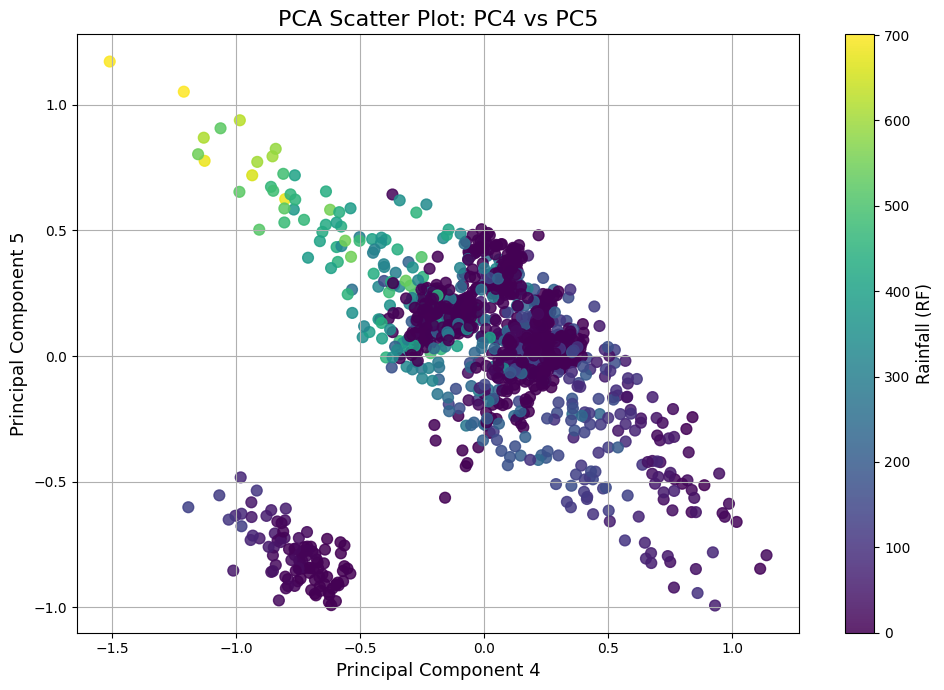

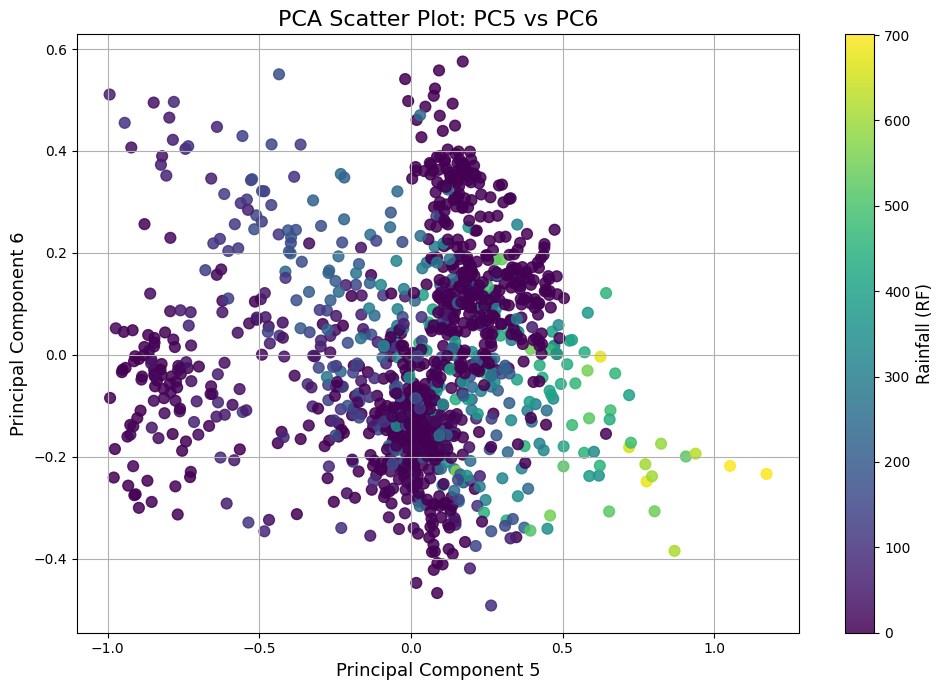

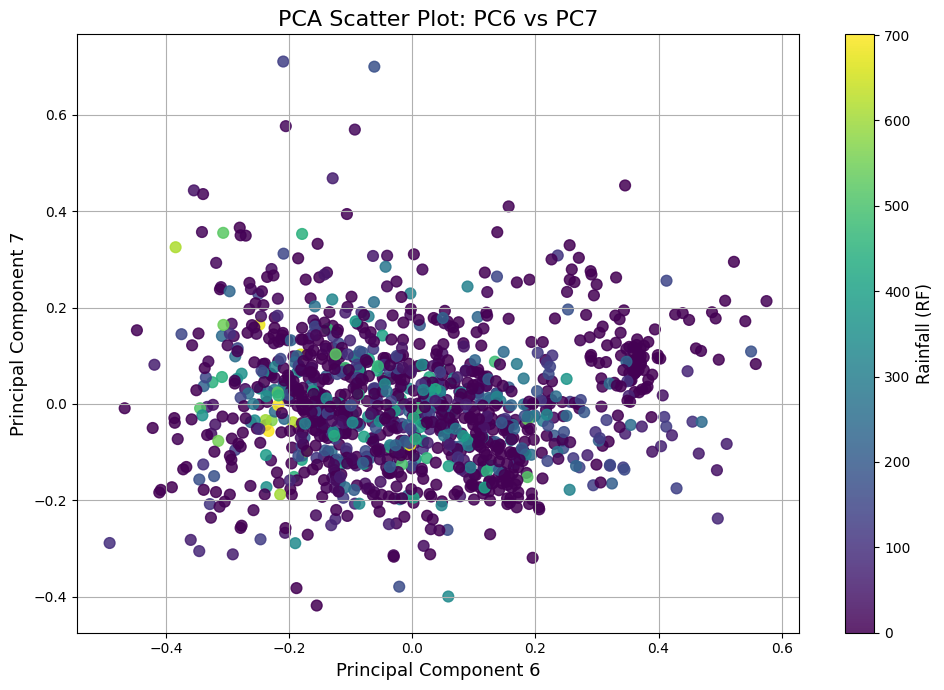

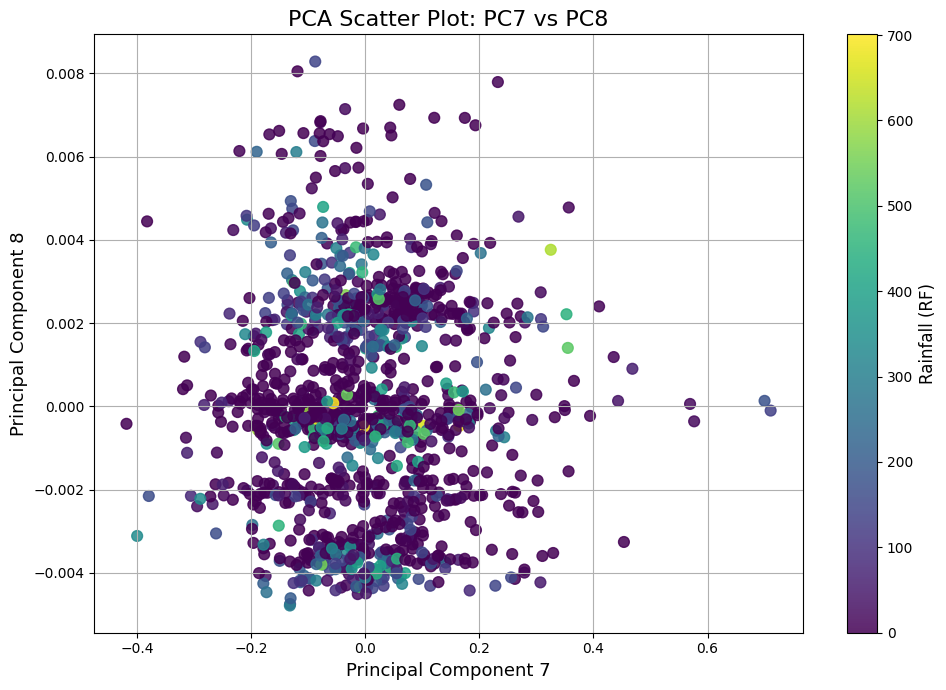


All PCA scatter plots saved successfully.


In [ ]:
# ============================================================
# ADVANCED PCA SCATTER PLOTS
# (LIKE YOUR UPLOADED IMAGE)
# FOR ALL PC COMBINATIONS
# ============================================================

# ----------------------------
# IMPORT LIBRARIES
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv('Vadodara_9_Para_CSV.csv')

# ------------------------------------------------
# SELECT VARIABLES FOR PCA
# ------------------------------------------------
X = df[['ATE','CC','DTR','MTE','PET','RCETO','VP','WDF']]

# ------------------------------------------------
# TARGET VARIABLE FOR COLOR
# ------------------------------------------------
rainfall = df['RF']

# ------------------------------------------------
# STANDARDIZE DATA
# ------------------------------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------
# APPLY PCA
# ------------------------------------------------
pca = PCA(n_components=8)

principal_components = pca.fit_transform(X_scaled)

# ------------------------------------------------
# CREATE PCA DATAFRAME
# ------------------------------------------------
pca_df = pd.DataFrame(
    principal_components,
    columns=[f'PC{i+1}' for i in range(8)]
)

# ============================================================
# PCA SCATTER PLOTS FOR ALL PCs
# ============================================================

# ------------------------------------------------
# PLOT:
# PC1 vs PC2
# PC2 vs PC3
# PC3 vs PC4
# ...
# PC7 vs PC8
# ------------------------------------------------

for i in range(7):

    plt.figure(figsize=(10,7))

    scatter = plt.scatter(
        pca_df[f'PC{i+1}'],
        pca_df[f'PC{i+2}'],

        c=rainfall,            # Color using rainfall
        cmap='viridis',        # Same as your image
        s=60,                  # Marker size
        alpha=0.85
    )

    # Axis Labels
    plt.xlabel(f'Principal Component {i+1}', fontsize=13)
    plt.ylabel(f'Principal Component {i+2}', fontsize=13)

    # Title
    plt.title(
        f'PCA Scatter Plot: PC{i+1} vs PC{i+2}',
        fontsize=16
    )

    # Colorbar
    cbar = plt.colorbar(scatter)

    cbar.set_label('Rainfall (RF)', fontsize=12)

    # Grid
    plt.grid(True)

    # Tight layout
    plt.tight_layout()

    # Show plot
    plt.show()

# ============================================================
# OPTIONAL:
# SAVE ALL FIGURES AUTOMATICALLY
# ============================================================

for i in range(7):

    plt.figure(figsize=(10,7))

    scatter = plt.scatter(
        pca_df[f'PC{i+1}'],
        pca_df[f'PC{i+2}'],

        c=rainfall,
        cmap='viridis',
        s=60,
        alpha=0.85
    )

    plt.xlabel(f'Principal Component {i+1}')
    plt.ylabel(f'Principal Component {i+2}')

    plt.title(f'PCA Scatter Plot: PC{i+1} vs PC{i+2}')

    cbar = plt.colorbar(scatter)

    cbar.set_label('Rainfall (RF)')

    plt.grid(True)

    plt.tight_layout()

    # SAVE FIGURE
    plt.savefig(
        f'PCA_PC{i+1}_vs_PC{i+2}.png',
        dpi=300
    )

    plt.close()

print("\nAll PCA scatter plots saved successfully.")